In [21]:
!pip install opencv-python
import cv2
import numpy as np
import time
import os
from queue import PriorityQueue

PI = 3.141592653589793238463
ZERO = 0.0
MINUS = -1.0
FALSE = 0  # Since we're not using OpenCV's Scalar class
CIRCLE = 360

def println(val):
    print(val)

def tic():
    return time.time()

def toc(start):
    elapsed = (time.time() - start)
    print(f"Elapsed {elapsed:2.10f} Seconds")
    return elapsed

def end_run(exit_code):
    input()
    return exit_code

def sign(x):
    if x > 0: return 1
    elif x < 0: return -1
    else: return 0

def nchoosek(n, k):
    if k == 0: return 1
    if n == 0: return 0
    return nchoosek(n - 1, k - 1) + nchoosek(n - 1, k)

def sub2ind(rows, cols, row, col):
    return cols * row + col

def mat_sub2ind(rows, cols, row, col):
    assert row.shape == col.shape
    return cols * row + col

def ind2sub(ind, cols, rows):
    row = ind // cols
    col = ind % cols
    return row, col

def exists(name):
    return os.path.exists(name)

def read_image(img_path, kill=False):
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print("Could not open or find the image")
        if kill:
            exit(-1)
    return image

def show_image(image, fig, scale=1, wait=False):
    i_big = cv2.resize(image, (0, 0), fx=scale, fy=scale)
    win_name = f"Window {fig}"
    cv2.namedWindow(win_name, cv2.WINDOW_AUTOSIZE)
    cv2.imshow(win_name, i_big)
    if wait:
        cv2.waitKey(0)

def find_indices(M):
    return np.nonzero(M.flatten())[0]

def copy_indices(D, ind):
    values = D.flatten()
    dest = np.zeros_like(ind, dtype=D.dtype)
    valid_indices = ind >= 0
    dest[valid_indices] = values[ind[valid_indices]]
    return dest

def set_value_if_true(value, dst, flag):
    if isinstance(value, (int, float)):
        dst[flag] = value
    else:
        dst[flag] = value[flag]

def keep_selected_rows(src, good_cols):
    return src[good_cols.flatten().astype(bool)]

def keep_selected_columns(src, good_cols):
    return src[:, good_cols.flatten().astype(bool)]

def keep_true(src, keep):
    return src.flatten()[keep.flatten().astype(bool)]

def set_values_in_ind(values, ind, dst):
    dst.flat[ind.astype(int)] = values

def max_value(m):
    return np.max(m)

def get_highest_k_values(src, k):
    flat_src = src.flatten()
    idx = np.argpartition(flat_src, -k)[-k:]
    idx = idx[np.argsort(-flat_src[idx])]
    return flat_src[idx], idx

def reorder(idx, src):
    return src.flatten()[idx.astype(int)]

def reorder_cols(idx, src):
    return src[:, idx.astype(int)]

def ind_to_angle(rows, cols, ind0, ind1):
    x0, y0 = ind2sub(ind0, cols, rows)
    x1, y1 = ind2sub(ind1, cols, rows)
    v1 = x1 - x0
    v2 = y1 - y0
    
    angle = np.pi/2 * sign(v2) if v1 == 0 else np.arctan(v2 / v1)
    angle *= 180 / PI
    ang = int(angle) + 360
    
    if v1 < 0:
        ang += 180
    ang = ang % 360
    
    assert 0 <= ang < 360
    return ang

def ind_to_angle_mat(rows, cols, ind0, ind1):
    ind0_flat = ind0.flatten()
    ind1_flat = ind1.flatten()
    angles = np.zeros_like(ind0_flat)
    
    for i in range(len(ind0_flat)):
        angles[i] = ind_to_angle(rows, cols, int(ind0_flat[i]), int(ind1_flat[i]))
    
    return angles.reshape(ind0.shape)


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import cv2
import numpy as np
from collections import defaultdict
from threading import Lock
from math import log, sqrt, pow

# Constants
TYPE = cv2.CV_64F
BOOL = cv2.CV_8U

ZERO = 0.0
MINUS = -1.0
FALSE = 0
CIRCLE = 360
PI = 3.141592653589793238463

'''
class MyParam:
    def __init__(self):
        # Remove bottom level lines with response lower than removeEpsilon x sigma
        self.removeEpsilon = 0.248

        # maxTurn is the maximal turn of the bottom levels
        self.maxTurn = 35

        # Edges with numFact overlap cannot be joined together to the final edge map
        self.nmsFact = 0.75

        # K splitPoints to consider in every interface
        self.splitPoints = 0  # 0 = allPoints

        # Edges with length greater than minContrast should pass the min-constrast test
        self.minContrast = 9  # 0 = noTest

        # Norm Type
        self.normType = 0  # 0 = max(dx,dy), 1 = dx+dy, 2 = sqrt(dx^2+dy^2)

        self.maxNumOfEdges = 50
        self.sigma = 0.1
        self.patchSize = 5
        self.filterWidth = 2
        self.parallel = True
        self.parallelJump = 1
        self.noisyImage = True  # false = lowerThreshold
        self.minLevelOfStitching = 0  # 0 = stichAll
        self.slidingWindow = int(pow(2, 8)) + 1  # 0 = allImage
        self.printToScreen = True
        self.interpolation = True
        self.fibers = False

    @staticmethod
    def matrix_maximum(x, y, dst):
        """Returns the maximum of two matrices"""
        assert x.shape == y.shape
        m1 = np.maximum(x, np.zeros_like(x))
        m2 = np.maximum(y, np.zeros_like(y))
        dst[:] = m1 + m2
'''
class Handle:
    def __init__(self):
        self.m = 0
        self.n = 0
        self.N = 0
        self.S = None
        self.rSize = None
        self.R = 0
        self.L = 1
        self.C = 2
        self.SC = 3
        self.minC = 4
        self.maxC = 5
        self.I0S0 = 6
        self.S0I1 = 7
        self.A0 = 8
        self.A1 = 9
        self.TOTAL = 10

'''
class Detector:
    def __init__(self, I, prm):
        self._I = I
        self._dX = None
        self._dY = None
        self._E = None
        self._w = 0
        self._filter = None
        self._prm = prm
        self._handle = Handle()
        self._data = defaultdict(lambda: None)
        self._pixel_scores = None
        self._pixels = defaultdict(lambda: None)
        self._debug = False
        self._mtx = Lock()
        self._max_level = 0

    def __del__(self):
        pass  # Python handles cleanup automatically

    def get_threshold(self, length):
        fact = 1 if self._prm.noisyImage else 0.0
        return self._prm.sigma * (fact * 0.14 + sqrt(2 * log(6 * self._handle.N) / self._w / length / 2))

    def get_side_length(self, m, n, e):
        return m if e == 0 else n

    def lock(self):
        self._mtx.acquire()

    def unlock(self):
        self._mtx.release()

    def get_angle(self, dx, dy):
        # Implementation needed
        pass

    def insert_value_to_map(self, index, key, value):
        # Implementation needed
        pass

    def get_E(self):
        return self._E

    def get_pixel_scores(self):
        P = self._pixel_scores[0]
        return P / np.max(P)

    def run_im(self):
        # Implementation needed
        pass

    def beam_curves(self, index, level, S):
        # Implementation needed
        pass

    # Private methods would follow here
    def _get_bottom_level_simple(self, S, index):
        # Implementation needed
        pass

    def _get_line(self, x0, y0, x1, y1, P, F):
        # Implementation needed
        pass

    def _get_line_filter(self, x0, y0, x1, y1, F):
        # Implementation needed
        pass

    def _interp_line(self, x, y, F, value):
        # Implementation needed
        pass
'''

'\nclass Detector:\n    def __init__(self, I, prm):\n        self._I = I\n        self._dX = None\n        self._dY = None\n        self._E = None\n        self._w = 0\n        self._filter = None\n        self._prm = prm\n        self._handle = Handle()\n        self._data = defaultdict(lambda: None)\n        self._pixel_scores = None\n        self._pixels = defaultdict(lambda: None)\n        self._debug = False\n        self._mtx = Lock()\n        self._max_level = 0\n\n    def __del__(self):\n        pass  # Python handles cleanup automatically\n\n    def get_threshold(self, length):\n        fact = 1 if self._prm.noisyImage else 0.0\n        return self._prm.sigma * (fact * 0.14 + sqrt(2 * log(6 * self._handle.N) / self._w / length / 2))\n\n    def get_side_length(self, m, n, e):\n        return m if e == 0 else n\n\n    def lock(self):\n        self._mtx.acquire()\n\n    def unlock(self):\n        self._mtx.release()\n\n    def get_angle(self, dx, dy):\n        # Implementation ne

In [23]:
import cv2
import numpy as np
from threading import Lock
import math
from queue import PriorityQueue
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

# Constants
TYPE = cv2.CV_64F
BOOL = cv2.CV_8U
ZERO = 0.0
MINUS = -1.0
FALSE = 0
CIRCLE = 360
PI = 3.141592653589793238463

@dataclass
class MyParam:
    def __init__(self):
        self.removeEpsilon = 0.248
        self.maxTurn = 35
        self.nmsFact = 0.75
        self.splitPoints = 0  # 0 = allPoints
        self.minContrast = 9  # 0 = noTest
        self.normType = 0  # 0 = max(dx,dy), 1 = dx+dy, 2 = sqrt(dx^2+dy^2)
        self.maxNumOfEdges = 50
        self.sigma = 0.1
        self.patchSize = 5
        self.filterWidth = 2
        self.parallel = True
        self.parallelJump = 1
        self.noisyImage = True  # false = lowerThreshold
        self.minLevelOfStitching = 0  # 0 = stichAll
        self.slidingWindow = int(pow(2, 8)) + 1  # 0 = allImage
        self.printToScreen = True
        self.interpolation = True
        self.normType = 0
        self.fibers = False

    @staticmethod
    def matrix_maximum(x: np.ndarray, y: np.ndarray, dst: np.ndarray):
        assert x.shape == y.shape
        m1 = np.maximum(x, np.zeros_like(x))
        m2 = np.maximum(y, np.zeros_like(y))
        dst[:] = m1 + m2

class Handle:
    def __init__(self):
        self.m = 0
        self.n = 0
        self.N = 0
        self.S = None
        self.rSize = None
        self.R = 0
        self.L = 1
        self.C = 2
        self.SC = 3
        self.minC = 4
        self.maxC = 5
        self.I0S0 = 6
        self.S0I1 = 7
        self.A0 = 8
        self.A1 = 9
        self.TOTAL = 10

'''
class Detector:
    def __init__(self, I: np.ndarray, prm: MyParam):
        self._I = I.astype(np.float64)
        self._w = prm.filterWidth
        self._prm = prm
        self._handle = Handle()
        self._data = [defaultdict(lambda: None) for _ in range(1000)]  # Adjust size as needed
        self._pixel_scores = []
        self._pixels = defaultdict(lambda: None)
        self._debug = False
        self._mtx = Lock()
        self._max_level = 0
        
        # Initialize filter
        if not prm.fibers:
            filter = np.zeros(2 * self._w + 1)
            filter[:self._w] = 1
            filter[self._w+1:] = -1
        else:
            filter = np.zeros(2 * self._w + 1)
            filter[:self._w] = -1
            filter[self._w+1:] = -1
            filter[self._w] = self._w * 2
            filter = filter / 2

        self._filter = filter.astype(np.float64)
        
        # Initialize derivatives
        self._dX = cv2.filter2D(self._I, -1, self._filter, borderType=cv2.BORDER_REFLECT)
        self._dY = cv2.filter2D(self._I, -1, self._filter.reshape(-1, 1), borderType=cv2.BORDER_REFLECT)
        self._E = np.zeros_like(self._I)

        # Initialize handle parameters
        m, n = self._I.shape
        self._handle.m = m
        self._handle.n = n
        self._handle.N = m * n
        self._handle.rSize = (self._handle.N, self._handle.N)
        
        max_size = int(np.ceil(self._handle.N / 3.0))
        self._pixel_scores = [None] * max_size

'''

'\nclass Detector:\n    def __init__(self, I: np.ndarray, prm: MyParam):\n        self._I = I.astype(np.float64)\n        self._w = prm.filterWidth\n        self._prm = prm\n        self._handle = Handle()\n        self._data = [defaultdict(lambda: None) for _ in range(1000)]  # Adjust size as needed\n        self._pixel_scores = []\n        self._pixels = defaultdict(lambda: None)\n        self._debug = False\n        self._mtx = Lock()\n        self._max_level = 0\n\n        # Initialize filter\n        if not prm.fibers:\n            filter = np.zeros(2 * self._w + 1)\n            filter[:self._w] = 1\n            filter[self._w+1:] = -1\n        else:\n            filter = np.zeros(2 * self._w + 1)\n            filter[:self._w] = -1\n            filter[self._w+1:] = -1\n            filter[self._w] = self._w * 2\n            filter = filter / 2\n\n        self._filter = filter.astype(np.float64)\n\n        # Initialize derivatives\n        self._dX = cv2.filter2D(self._I, -1, self._

In [28]:
import numpy as np
import cv2
import time
from queue import PriorityQueue
from threading import Lock, Thread
import math
from dataclasses import dataclass
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
import heapq

PI = math.pi
CIRCLE = 360
TYPE = np.float64
ZERO = 0.0
FALSE = False
BOOL = bool

@dataclass
class Handle:
    m: int = 0  # rows
    n: int = 0  # cols 
    N: int = 0  # total pixels
    S: np.ndarray = None
    rSize: Tuple[int, int] = (0, 0)
    TOTAL: int = 10  # Total number of fields in data structure
    # Data structure field indices
    C: int = 0    # Contrast
    I0S0: int = 1 # First subsegment index
    L: int = 2    # Length
    R: int = 3    # Response
    S0I1: int = 4 # Second subsegment index
    SC: int = 5   # Score
    minC: int = 6 # Min contrast
    maxC: int = 7 # Max contrast
    A0: int = 8   # Start angle
    A1: int = 9   # End angle

'''
@dataclass
class MyParam:
    filterWidth: int = 2
    fibers: bool = False
    patchSize: int = 16
    parallel: bool = True
    parallelJump: int = 2
    minLevelOfStitching: int = 0
    printToScreen: bool = True
    normType: int = 2
    interpolation: bool = True
    removeEpsilon: float = 0.248
    sigma: float = 0.1
    minContrast: float = 9.0
    maxTurn: int = 35
    splitPoints: int = 0
    nmsFact: float = 0.75
    maxNumOfEdges: int = 1000
'''

def read_image(img_path: str, kill: bool = False) -> np.ndarray:
    """Read image in grayscale"""
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print("Could not open or find the image")
        if kill:
            exit(-1)
    return image

def show_image(image: np.ndarray, fig: int, scale: float = 1, wait: bool = False):
    """Display image with matplotlib"""
    plt.figure(fig)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.show()
    if wait:
        plt.pause(0.1)

class Detector:
    def __init__(self, I: np.ndarray, prm: MyParam):
        self._prm = prm
        self._w = prm.filterWidth
        self._debug = False
        self._maxLevel = 0
        self._mtx = Lock()
        self._handle = Handle()
        self._pixels = {}  # Dict[int, np.ndarray]
        
        # Create filter
        if not prm.fibers:
            filter = np.zeros(2 * self._w + 1, dtype=TYPE)
            filter[:self._w] = 1
            filter[self._w+1:] = -1
        else:
            filter = np.zeros(2 * self._w + 1, dtype=TYPE)
            filter[:self._w] = -1
            filter[self._w+1:] = -1
            filter[self._w] = self._w * 2
            filter /= 2
            
        # Convert image and filter
        self._I = I.astype(TYPE)
        self._filter = filter.astype(TYPE)
        self._E = np.zeros_like(self._I, dtype=TYPE)
        
        # Calculate gradients
        self._dX = cv2.filter2D(self._I, -1, self._filter, borderType=cv2.BORDER_REFLECT)
        self._dY = cv2.filter2D(self._I, -1, self._filter.reshape(-1,1), borderType=cv2.BORDER_REFLECT)
        
        # Initialize handles
        m, n = self._I.shape
        N = n * m
        self._handle.m = m
        self._handle.n = n
        self._handle.N = N
        self._handle.rSize = (N, N)
        
        # Initialize data structures
        max_size = int(np.ceil(N/3.0))
        self._pixelScores = [np.zeros((m,n), dtype=TYPE) for _ in range(max_size)]
        self._data = [{} for _ in range(max_size)]
        
        if self._debug:
            print(self._I)
            print(self._filter)
            print(self._dY)
            print(self._dX)

    def get_angle(self, dx: float, dy: float) -> int:
        """Calculate angle from dx and dy components.
        
        Args:
            dx (float): Change in x direction
            dy (float): Change in y direction
            
        Returns:
            int: Angle in degrees (0-360)
        """
        v1 = dx
        v2 = dy
        
        # Calculate angle in radians and convert to degrees
        if v1 ==0:
            v1 = 0.0001
        angle = math.atan(v2/v1)
        angle *= CIRCLE / (2 * PI)
        
        # Adjust angle based on quadrant
        if v1 < 0:
            angle += CIRCLE / 2
        
        # Normalize angle to range [0, CIRCLE)
        a = int(angle) % CIRCLE
        if a < 0:
            a += CIRCLE
        
        # Validate angle range
        assert 0 <= a <= CIRCLE, f"Invalid angle: {a}"
        
        # Debug output if needed
        if self._debug:
            print(v1)
            print(v2)
            print(a)
        
        return a
    
    def run_im(self):
        """
        Run the edge detection algorithm by building a binary tree 
        and creating the edge image.
        
        Returns:
            numpy.ndarray: The edge detection result
        """
        m = self._handle.m
        n = self._handle.n
        
        start = 0
        if self._prm.printToScreen:
            print("Build Binary Tree")
            start = time.time()
        
        # Create matrix S with sequential indices
        S = np.arange(m * n, dtype=np.float64).reshape(m, n)
        
        # Store width and copy S to handle
        w = self._w
        self._handle.S = S.copy()
        
        # Build the beam curves binary tree
        self.beam_curves(0, 0, S)
        
        if self._prm.printToScreen:
            elapsed = time.time() - start
            print(f"Elapsed {elapsed:.10f} Seconds")
            print("Create Edge Image")
            start = time.time()
        
        # Generate edge scores
        self.get_scores()
        
        if self._prm.printToScreen:
            elapsed = time.time() - start
            print(f"Elapsed {elapsed:.10f} Seconds")
        
        return self._E

    def get_line_filter(self, x0: int, y0: int, x1: int, y1: int, F: np.ndarray) -> None:
        """Create a filtered line between two points.
        
        Args:
            x0 (int): Starting x coordinate
            y0 (int): Starting y coordinate
            x1 (int): Ending x coordinate
            y1 (int): Ending y coordinate
            F (np.ndarray): Filter matrix to store the line values
        """
        dx = x1 - x0
        dy = y1 - y0
        L = int(np.maximum(abs(dx), abs(dy)))
        bigger_x = abs(dx) >= abs(dy)
        
        # Calculate step sizes
        x_loop = dx > 0 if bigger_x else dx / abs(dy)
        y_loop = dy > 0 if not bigger_x else dy / abs(dx)
        
        corner = 0.5
        cur_x = x0
        cur_y = y0
        
        # Draw filtered line
        for j in range(L + 1):
            if j == 0 or j == L:
                self.interp_line(round(cur_x), round(cur_y), F, corner)
            else:
                self.interp_line(cur_x, cur_y, F, 1.0)
            cur_x += x_loop
            cur_y += y_loop
    
    def interp_line(self, x: float, y: float, F: np.ndarray, value: float) -> None:
        """Update filter matrix values using linear interpolation.
        
        Args:
            x (float): x coordinate
            y (float): y coordinate
            F (np.ndarray): Filter matrix to update
            value (float): Value to interpolate
        """
        if round(x) == x:
            # Vertical interpolation
            dy = y - math.floor(y)
            F[int(x), int(math.floor(y))] = value * (1 - dy)
            if dy > 0:
                F[int(x), int(math.ceil(y))] = value * dy
        elif round(y) == y:
            # Horizontal interpolation
            dx = x - math.floor(x)
            F[int(math.floor(x)), int(y)] = value * (1 - dx)
            if dx > 0:
                F[int(math.ceil(x)), int(y)] = value * dx
        else:
            print("Interp Error")
        
    def sub_im(self,S,a,b,c,d):
        return S[a:c+1,b:d+1]
    
    def get_bottom_level_simple(self, S, index):
        """Get simple bottom level edges.
        
        Args:
            S (np.ndarray): Input matrix of indices
            index (int): Current index value
        """
        m, n = S.shape
        base_ind = int(S[0, 0])
        row, col = ind2sub(base_ind, self._I.shape[1], self._I.shape[0])
        
        # Get sub-images
        gx = self.sub_im(self._dX, row, col, row + m - 1, col + n - 1)
        gy = self.sub_im(self._dY, row, col, row + m - 1, col + n - 1)
        ss = self.sub_im(self._handle.S, row, col, row + m - 1, col + n - 1)
        #print('Bottom Level')
        # Iterate through edge combinations
        for e0 in range(1, 4):
            for e1 in range(e0 + 1, 5):
                len0 = self.get_side_length(m, n, e0)
                for v0 in range(len0):
                    x0, y0 = self.get_vertices_from_patch_indices(e0, v0, m, n)
                    len1 = self.get_side_length(m, n, e1)
                    
                    for v1 in range(len1):
                        x1, y1 = self.get_vertices_from_patch_indices(e1, v1, m, n)
                        ind0 = int(S[x0, y0])
                        ind1 = int(S[x1, y1])
                        #print(f'ind0 {ind0} ind1 {ind1}')
                        if ind0 == ind1:
                            continue
                        
                        P = np.zeros((m, n), dtype=np.float64)
                        F = np.zeros((m, n), dtype=np.float64)
                        
                        len_val = self.get_line(x0, y0, x1, y1, P, F)
                        dx = float(x1 - x0)
                        dy = float(y1 - y0)
                        angle = self.get_angle(dx, dy)
                        adx = abs(dx)
                        ady = abs(dy)
                        
                        # Calculate length based on norm type
                        if self._prm.normType == 0:
                            len_val = np.maximum(adx, ady)
                        elif self._prm.normType == 1:
                            len_val = adx + ady
                        elif self._prm.normType == 2:
                            len_val = np.sqrt(adx**2 + ady**2)
                        
                        cur_indices = np.nonzero(P)
                        cur_pixels = S[cur_indices]
                        
                        # Calculate response
                        if self._prm.interpolation:
                            resp_x = np.sign(dx) * np.sum(F * gx)
                            resp_y = -np.sign(dy) * np.sum(F * gy)
                        else:
                            resp_x = np.sign(dx) * np.sum(P * gx)
                            resp_y = -np.sign(dy) * np.sum(P * gy)
                        
                        if abs(dx) > abs(dy):
                            resp = resp_x
                        else:
                            resp = resp_y
                        
                        con = resp / (2 * self._w * len_val)
                        good = abs(con) >= (self._prm.removeEpsilon * self._prm.sigma)
                        #print(f'con {con} resp {resp} good {good} w {self._w} len {len_val} sigma {self._prm.sigma}')
                        
                        if not good:
                            continue
                        
                        # Calculate score
                        if len_val <= 0:
                            score = float('-inf')
                        else:
                            thresh = self.get_threshold(len_val)
                            score = abs(con) - thresh
                        
                        # Create indices for data storage
                        ind01 = sub2ind(self._handle.rSize[0], self._handle.rSize[1], ind0, ind1)
                        ind10 = sub2ind(self._handle.rSize[0], self._handle.rSize[1], ind1, ind0)
                        
                        # Create best data arrays
                        best_data = np.zeros(self._handle.TOTAL)
                        best_data[self._handle.C] = con
                        best_data[self._handle.I0S0] = 0
                        best_data[self._handle.L] = len_val
                        best_data[self._handle.R] = resp
                        best_data[self._handle.S0I1] = 0
                        best_data[self._handle.SC] = score
                        best_data[self._handle.minC] = con
                        best_data[self._handle.maxC] = con
                        best_data[self._handle.A0] = angle
                        best_data[self._handle.A1] = angle
                        
                        # Create reversed best data
                        best_data2 = best_data.copy()
                        best_data2[self._handle.R] = -best_data[self._handle.R]
                        best_data2[self._handle.C] = -best_data[self._handle.C]
                        best_data2[self._handle.minC] = -best_data[self._handle.maxC]
                        best_data2[self._handle.maxC] = -best_data[self._handle.minC]
                        angle2 = int(angle + 0.5 * CIRCLE) % CIRCLE
                        best_data2[self._handle.A0] = angle2
                        best_data2[self._handle.A1] = angle2
                        
                        # Insert values into maps
                        #print('Insert Values Bottom Level')
                        self.insert_value_to_map(index, ind01, best_data.copy())
                        self.insert_value_to_map(index, ind10, best_data2.copy())
                        
                        # Update pixel scores
                        value = abs(resp)
                        if value > 0:
                            px = self._pixelScores[index]
                            x,y = ind2sub(ind0,self._handle.m, self._handle.n)
                            px[x,y] = np.maximum(px[x,y], value)
                            x,y = ind2sub(ind1,self._handle.m, self._handle.n)
                            px[x,y] = np.maximum(px[x,y], value)
                        
                        # Update pixels with lock
                        self.lock()
                        self._pixels[ind01] = cur_pixels.copy()
                        self._pixels[ind10] = cur_pixels.copy()
                        self.unlock()
            
    def get_vertices_from_patch_indices(self, e, v, m, n):
        """Get vertex coordinates from patch indices.
        
        Args:
            e (int): Edge number (1-4)
            v (int): Vertex index
            m (int): Number of rows
            n (int): Number of columns
            
        Returns:
            tuple: (x, y) coordinates
        """
        if e == 1:  # Top edge
            return 0, v
        elif e == 2:  # Right edge
            return v, n-1
        elif e == 3:  # Bottom edge
            return m-1, v
        elif e == 4:  # Left edge
            return v, 0
        else:
            raise ValueError(f"Invalid edge number: {e}")

    def get_side_length(self, m: int, n: int, e: int) -> int:
        """Get side length based on edge number.
        
        Args:
            m (int): Number of rows
            n (int): Number of columns
            e (int): Edge number
        
        Returns:
            int: Length of the side (m for odd edges, n for even edges)
        """
        return m if e % 2 == 1 else n

    def matrix_maximum(self, x: np.ndarray, y: np.ndarray, dst: np.ndarray) -> None:
        """Calculate element-wise maximum of two matrices and store result in dst.
        
        Args:
            x (np.ndarray): First input matrix
            y (np.ndarray): Second input matrix
            dst (np.ndarray): Destination matrix for results
        """
        assert x.shape == y.shape, "Input matrices must have same shape"
        
        # Create zero matrices same size as inputs
        m1 = np.zeros_like(x)
        m2 = np.zeros_like(y)
        
        # Get element-wise maximum between inputs and zeros
        np.maximum(x, m1, out=m1)
        np.maximum(y, m2, out=m2)
        
        # Add results and store in destination
        dst[:] = m1 + m2


    
    def beam_curves(self, index: int, level: int, S: np.ndarray):
        """
        Construct the Beam-Curve Binary-Tree of a rectangular image.
        
        Args:
            index: Current node index in the binary tree
            level: Current level in the binary tree
            S: Input matrix
        """
        m, n = S.shape
        self._pixelScores[index] = np.zeros((self._handle.m, self._handle.n), dtype=np.float64)
        #print(f'Index {index} Level {level} Shape {m},{n}')
        if max(m, n) <= self._prm.patchSize:
            self._max_level = level
            self.get_bottom_level_simple(S, index)
        else:
            # Split image into quadrants
            vertical_split = n >= m
            s1len = 2
    
            if vertical_split:
                mid1 = n // 2
                mid2 = m // 2
                S0 = self.sub_im(S, 0, 0, m-1, mid1)
                S1 = self.sub_im(S, 0, mid1, m-1, n-1)
                S2 = self.sub_im(S, 0, 0, mid2, n-1)
                S3 = self.sub_im(S, mid2, 0, m-1, n-1)
            else:
                mid1 = m // 2
                mid2 = n // 2
                S0 = self.sub_im(S, 0, 0, mid1, n-1)
                S1 = self.sub_im(S, mid1, 0, m-1, n-1)
                S2 = self.sub_im(S, 0, 0, m-1, mid2)
                S3 = self.sub_im(S, 0, mid2, m-1, n-1)
    
            if self._debug:
                print("Tiling:")
                print(S)
                print(S0)
                print(S1)
    
            t = [2 * index + 1, 2 * index + 2]
            S_arr1 = [S0, S1]
            S_arr2 = [S2, S3]
    
            # Handle parallel processing
            if self._prm.parallel and level % self._prm.parallelJump == 0:
                threads = []
                for i in range(s1len):
                    thread = Thread(target=self.beam_curves, 
                                  args=(t[i], level + 1, S_arr1[i]))
                    threads.append(thread)
                    thread.start()
                
                for thread in threads:
                    thread.join()
            else:
                for i in range(s1len):
                    self.beam_curves(t[i], level + 1, S_arr1[i])
    
            # Update pixel scores
            self.matrix_maximum(
                self._pixelScores[t[0]], 
                self._pixelScores[t[1]], 
                self._pixelScores[index]
            )
    
            for i in range(s1len):
                self._pixelScores[t[i]] = None  # Python equivalent of release()
    
            # Merge tiles if needed
            if self._prm.minLevelOfStitching == 0 or level >= self._prm.minLevelOfStitching:
                self.merge_tiles_simple(S0, S1, index, level, vertical_split)
                if vertical_split:
                    self.merge_tiles_simple(S2, S3, index, level, not vertical_split)
    
            # Transfer data from children to parent
            for i in range(s1len):
                for key, value in self._data[t[i]].items():
                    self.insert_value_to_map(index, float(key), value.copy())
                self._data[t[i]].clear()
    
            # Print level completion
            j = math.log2(index + 2)
            if self._prm.printToScreen and math.ceil(j) == j:
                print(f"Level {int(j)} Complete")

    def get_line(self, x0: int, y0: int, x1: int, y1: int, P: np.ndarray, F: np.ndarray) -> int:
        """Draw a line between two points using Bresenham's algorithm and return the line length.
        
        Args:
            x0 (int): Starting x coordinate
            y0 (int): Starting y coordinate
            x1 (int): Ending x coordinate
            y1 (int): Ending y coordinate
            P (np.ndarray): Binary matrix to mark the line points
            F (np.ndarray): Filter matrix for line points
            
        Returns:
            int: Length of the line (maximum of dx and dy)
        """
        # Get the filter matrix first
        self.get_line_filter(x0, y0, x1, y1, F)
        
        # Calculate absolute differences and line length
        dx = abs(x1 - x0)
        dy = abs(y1 - y0)
        L = np.maximum(dx, dy)
        
        # Determine step directions
        sx = 1 if x0 < x1 else -1
        sy = 1 if y0 < y1 else -1
        
        # Initial error term
        err = dx - dy
        
        # Line drawing flags and constants
        first = True
        corner = 0.5
        
        # Bresenham's line algorithm
        while True:
            P[x0, y0] = 1.0
            if first:
                P[x0, y0] = corner
                first = False
                
            if x0 == x1 and y0 == y1:
                P[x0, y0] = corner
                break
                
            e2 = 2 * err
            if e2 > -dy:
                err = err - dy
                x0 = x0 + sx
            if e2 < dx:
                err = err + dx
                y0 = y0 + sy
                
        return L

    
    def merge_tiles_simple(self, S1: np.ndarray, S2: np.ndarray, index: int, level: int, vertical_split: bool) -> None:
        """Merge two tiles and find best responses between their edges.
        
        Args:
            S1 (np.ndarray): First tile (upper/leftmost)
            S2 (np.ndarray): Second tile
            index (int): Current index
            level (int): Current level
            vertical_split (bool): Whether split is vertical
        """
        # Get edge indices for both tiles
        edge_S1 = self.get_edge_indices(S1)
        edge_S2 = self.get_edge_indices(S2)
        split = np.array([])
        
        if vertical_split:
            # Get best splitting points from right edge of S1
            split = self.get_best_splitting_points(edge_S1[2], split, index)
            
            # Process edges
            for i in range(len(edge_S1)):
                if i == 2:  # skip split of left rectangle
                    continue
                
                self.find_best_response(edge_S1[i], split, edge_S1[i], index, level)
                
                for j in range(len(edge_S2)):
                    if j == 0 or i == j:  # skip split of right rectangle and same sides
                        continue
                    self.find_best_response(edge_S1[i], split, edge_S2[j], index, level)
        else:
            # Get best splitting points from bottom edge of S1
            split = self.get_best_splitting_points(edge_S1[3], split, index)
            
            # Process edges
            for i in range(len(edge_S1)):
                if i == 3:  # skip split of upper rectangle
                    continue
                    
                self.find_best_response(edge_S1[i], split, edge_S1[i], index, level)
                
                for j in range(len(edge_S2)):
                    if j == 1 or i == j:  # skip split of lower rectangle and same sides
                        continue
                    self.find_best_response(edge_S1[i], split, edge_S2[j], index, level)
    
    def find_best_response(self, edge1: np.ndarray, split: np.ndarray, edge2: np.ndarray, 
                          index: int, level: int) -> None:
        """Find best responses between two fixed tile sides.
        
        Args:
            edge1 (np.ndarray): First edge
            split (np.ndarray): Split points
            edge2 (np.ndarray): Second edge
            index (int): Current index
            level (int): Current level
        """
        index1 = 2 * index + 1
        index2 = 2 * index + 2
        
        for ind0 in edge1.flat:
            for ind1 in edge2.flat:
                if ind0 == ind1:
                    continue
                    
                if self._debug:
                    print(f"{ind0},{ind1}")
                    
                best_data = np.zeros(self._handle.TOTAL)
                best_values1 = None
                best_values2 = None
                best_score = 0
                best_s0 = -1

                for s0 in split.flat:
                    if ind0 == s0 or ind1 == s0:
                        continue
                        
                    ind0s0 = sub2ind(self._handle.rSize[0], self._handle.rSize[1], int(ind0), int(s0))
                    s0ind1 = sub2ind(self._handle.rSize[0], self._handle.rSize[1], int(s0), int(ind1))
                    
                    if self._debug:
                        print(f"{ind0s0 in self._data[index1]}")
                        print(f"{s0ind1 in self._data[index2]}")
                        
                    #index1 = 0
                    #index2 = 0
                    if ind0s0 not in self._data[index1].keys() or s0ind1 not in self._data[index2].keys():
                        #print(self._data[index1])
                        #print('Continue Best Response')
                        continue
                        
                    ind_values1 = self._data[index1][ind0s0].copy()
                    ind_values2 = self._data[index2][s0ind1].copy()
                    
                    # Check angle difference
                    ang1_0 = int(ind_values1[self._handle.A0])
                    ang1_1 = int(ind_values1[self._handle.A1])
                    ang2_0 = int(ind_values2[self._handle.A0])
                    ang2_1 = int(ind_values2[self._handle.A1])
                    ang_diff = abs(ang1_1 - ang2_0) % CIRCLE
                    
                    if ang_diff > self._prm.maxTurn and ang_diff < (CIRCLE - self._prm.maxTurn):
                        if self._debug:
                            print("Angle not in range!")
                        continue
                    
                    # Calculate scores
                    len1 = ind_values1[self._handle.L]
                    len2 = ind_values2[self._handle.L]
                    resp1 = ind_values1[self._handle.R]
                    resp2 = ind_values2[self._handle.R]
                    
                    length = len1 + len2
                    assert len1 >= 1 and len2 >= 1
                    
                    resp = resp1 + resp2
                    con = resp/length if self._w == 0 else resp/(2 * self._w * length)
                    thresh = self.get_threshold(length)
                    score = abs(con) - thresh
                    #print(score)
                    if score > best_score or best_s0 < 0:
                        best_data[self._handle.C] = con
                        best_data[self._handle.I0S0] = ind0s0
                        best_data[self._handle.L] = length
                        best_data[self._handle.R] = resp
                        best_data[self._handle.S0I1] = s0ind1
                        best_data[self._handle.SC] = score
                        best_data[self._handle.A0] = ang1_0
                        best_data[self._handle.A1] = ang2_1
                        best_values1 = ind_values1.copy()
                        best_values2 = ind_values2.copy()
                        best_s0 = s0
                        best_score = score
                
                if best_s0 >= 0:
                    self._update_best_data(index, ind0, ind1, best_s0, best_data, 
                                         best_values1, best_values2)
    
    def get_best_splitting_points(self, split: np.ndarray, dst: np.ndarray, index: int) -> None:
        """Get the best K points on the interface.
        
        Args:
            split (np.ndarray): Split points array
            dst (np.ndarray): Destination array
            index (int): Current index
        """
        length = split.size
        if (self._prm.splitPoints >= length) or (self._prm.splitPoints == 0):
            dst = split.copy()
            return dst
        
        split_score = np.zeros_like(split, dtype=np.float64)
        self._copy_indices(self._pixelScores[index], split, split_score)
        
        P = self._prm.splitPoints
        values, indices = self._get_highest_k_values(split_score, P)
        
        for idx in indices:
            dst.append(split.flat[idx])
    
    
    def _update_best_data(self, index: int, ind0: int, ind1: int, best_s0: float, 
                         best_data: np.ndarray, best_values1: np.ndarray, 
                         best_values2: np.ndarray) -> None:
        """Update best data and maps with new values.
        
        Args:
            index (int): Current index
            ind0 (int): First index
            ind1 (int): Second index
            best_s0 (float): Best split point
            best_data (np.ndarray): Best data array
            best_values1 (np.ndarray): First best values
            best_values2 (np.ndarray): Second best values
        """
        ind01 = sub2ind(self._handle.rSize[0], self._handle.rSize[1], int(ind0), int(ind1))
        ind10 = sub2ind(self._handle.rSize[0], self._handle.rSize[1], int(ind1), int(ind0))
        ind1s0 = sub2ind(self._handle.rSize[0], self._handle.rSize[1], int(ind1), int(best_s0))
        s0ind0 = sub2ind(self._handle.rSize[0], self._handle.rSize[1], int(best_s0), int(ind0))
        
        if best_data[self._handle.L] <= self._prm.minContrast:
            best_data[self._handle.minC] = best_data[self._handle.C]
            best_data[self._handle.maxC] = best_data[self._handle.C]
        else:
            min_c = np.minimum(best_values1[self._handle.minC], best_values2[self._handle.minC])
            max_c = np.maximum(best_values1[self._handle.maxC], best_values2[self._handle.maxC])
            best_data[self._handle.minC] = min_c
            best_data[self._handle.maxC] = max_c
        
        best_value = abs(best_data[self._handle.R])
        if best_value > 0:
            px = self._pixelScores[index]
            x,y = ind2sub(ind0, self._handle.m, self._handle.n)
            px[int(x), int(y)] = np.maximum(px[int(x), int(y)], best_value)
            x,y = ind2sub(ind1, self._handle.m, self._handle.n)
            px[int(x), int(y)] = np.maximum(px[int(x), int(y)], best_value)
        
        # Create reversed data
        best_data2 = best_data.copy()
        best_data2[self._handle.R] = -best_data[self._handle.R]
        best_data2[self._handle.C] = -best_data[self._handle.C]
        best_data2[self._handle.minC] = -best_data[self._handle.maxC]
        best_data2[self._handle.maxC] = -best_data[self._handle.minC]
        best_data2[self._handle.I0S0] = ind1s0
        best_data2[self._handle.S0I1] = s0ind0
        best_data2[self._handle.A0] = int(best_data[self._handle.A1] + 0.5*CIRCLE) % CIRCLE
        best_data2[self._handle.A1] = int(best_data[self._handle.A0] + 0.5*CIRCLE) % CIRCLE
        
        self.insert_value_to_map(index, ind01, best_data.copy())
        self.insert_value_to_map(index, ind10, best_data2.copy())


    def get_edge_indices(self, S: np.ndarray) -> list[np.ndarray]:
        """Get indices for all edges of a matrix.
        
        Args:
            S (np.ndarray): Input matrix
            
        Returns:
            list[np.ndarray]: List of four edge arrays in order [left, top, right, bottom]
        """
        m, n = S.shape
        
        v = [
            S[:, 0].reshape(1, -1),    # left edge
            S[0, :],                   # top edge
            S[:, n-1].reshape(1, -1),  # right edge
            S[m-1, :]                  # bottom edge
        ]
        
        return v

    def get_scores(self):
        """Process and filter edges based on scores and non-maximum suppression."""
        m = self._handle.m
        n = self._handle.n
        
        selected = np.zeros((m, n), dtype=np.uint8)  # BOOL type
        data = self._data[0]
        #print(data)
        
        # Priority queue for scores
        q = []  # Will use heapq with negated scores for max-heap behavior
        
        # Process all edges in data
        for key, tuple_data in data.items():
            sc = tuple_data[self._handle.SC]
            con = tuple_data[self._handle.C]
            min_c = tuple_data[self._handle.minC]
            max_c = tuple_data[self._handle.maxC]
            L = tuple_data[self._handle.L]
            #print(sc)
            if sc > 0:
                #print('Positive')
                min_test = (L <= self._prm.minContrast or 
                           self._prm.minContrast == 0 or 
                           (con > 0 and min_c >= (con / 2)) or 
                           (con < 0 and max_c <= (con / 2)))
                
                if min_test:
                    # Use negative score for max-heap behavior
                    heapq.heappush(q, (-sc, key))
                    #print('Pushed to Heap')
        
        counter = 0
        before = len(q)
        
        while q:
            cur_score = -q[0][0]  # Negate back to positive
            cur_key = q[0][1]
            row, col = ind2sub(cur_key, self._handle.N, self._handle.N)
            
            heapq.heappop(q)
            E = np.zeros((m, n), dtype=np.uint8)
            
            if self._debug:
                print(f"Ind0 = {row}")
                print(f"Ind1 = {col}")
                print(cur_score)
            flag, E = self.add_edge(data, cur_key, E, 1)
            #print(E)
            if not flag:
                continue
                #temp = -1
            elif self._prm.nmsFact == 0:
                cur = E.astype(np.float64) * cur_score
                self._E = np.maximum(self._E, cur)
                counter += 1
                
            else:
                if self._debug:
                    e = np.ones((self._handle.m, self._handle.n), dtype=np.float64)
                    r, c = ind2sub(cur_key, self._handle.N, self._handle.N)
                    e[r] = 0
                    e[c] = 0
                    H = np.hstack((E.astype(np.float64), e))
                    print(e)
                    self.show_image(H, 1, round(129 / n * 2), True)
                
                cur_i = E.copy()
                L = np.sum(cur_i)
                h, w = cur_i.shape
                
                # Create dilated version
                hor_false = np.zeros((1, w), dtype=np.uint8)
                ver_false = np.zeros((h, 1), dtype=np.uint8)
                
                sub1 = np.vstack((hor_false, cur_i[:-1, :]))
                sub2 = np.vstack((cur_i[1:, :], hor_false))
                sub3 = np.hstack((cur_i[:, 1:], ver_false))
                sub4 = np.hstack((ver_false, cur_i[:, :-1]))
                
                cur_i_dilate = cur_i | sub1 | sub2 | sub3 | sub4
                coor = cur_i_dilate & selected
                
                if self._debug:
                    print(selected)
                    print(cur_i_dilate)
                    print(coor)
                
                nms_score = np.sum(coor) / L
                
                if nms_score < self._prm.nmsFact:
                    if self._debug:
                        print(L)
                    
                    self._remove_key(data, cur_key)
                    counter += 1
                    selected = selected | cur_i_dilate
                    cur = E.astype(np.float64) * cur_score
                    self._E = np.maximum(self._E, cur)
                    
                    if counter > self._prm.maxNumOfEdges:
                        return
        
        if self._prm.printToScreen:
            print(f"EdgesBeforeNMS = {before}\nEdgesAfterNMS = {counter}")


    def _remove_key(self, data: dict, key: int) -> None:
        """Remove a key from the data dictionary.
        
        Args:
            data (dict): Data dictionary
            key (int): Key to remove
        """
        if key in data:
            del data[key]
    
    def add_edge(self, data: dict, cur_key: int, E: np.ndarray, level: int) -> bool:
        """Add edge to the edge map recursively.
        
        Args:
            data (dict): Data dictionary containing edge information
            cur_key (int): Current edge key
            E (np.ndarray): Edge map to update
            level (int): Current recursion level
            
        Returns:
            bool: True if edge was added successfully, False otherwise
        """
        # Check termination conditions
        if cur_key not in data or level == self._max_level + 1:
            return False, E
            
        # Get current edge data
        cur_data = data[cur_key].copy()
        
        # Get split point indices
        i0s0 = int(cur_data[self._handle.I0S0])
        s0i1 = int(cur_data[self._handle.S0I1])
        
        # Adjust indices if they match current key
        i0s0 = (1 - (cur_key == i0s0)) * i0s0
        s0i1 = (1 - (cur_key == s0i1)) * s0i1
        
        if i0s0 > 0 and s0i1 > 0:
            # Recursively process split edges
            flag, E = self.add_edge(data, i0s0, E, level+1)
            if not flag:
                return False, E
            flag, E = self.add_edge(data, s0i1, E, level+1)
            if not flag:
                return False, E
        else:
            # Process leaf edge
            if cur_key not in self._pixels:
                print("Pixels Problem")
                return False
                
            pixels = self._pixels[cur_key]
            flag = False
            
            # Update edge map with pixel values
            for pixel in pixels.flat:
                cur_pixel = int(pixel)
                if cur_pixel >= 0:
                    flag = True
                    E.flat[cur_pixel] = True
                    
            if not flag:
                return False, E
                
        return True, E

    def insert_value_to_map(self, index: int, key: float, value: np.ndarray) -> bool:
        """Insert value into data map if it has a better score than existing value.
        
        Args:
            index (int): Data map index
            key (float): Map key
            value (np.ndarray): Value to insert
            
        Returns:
            bool: True if value was inserted, False otherwise
        """
        key = int(key)  # Convert float key to int for dictionary
        #index = 0
        #print('Add key value')
        # If key doesn't exist, insert value and return
        if key not in self._data[index].keys():
            
            self._data[index][key] = value
            #print(self._data[index])
            return True
            
        # Compare scores with existing value
        cur_value = self._data[index][key]
        better_score = cur_value[self._handle.SC] <= value[self._handle.SC]
        
        # Update if new score is better
        if better_score:
            self._data[index][key] = value
            return True
            
        return False

    def get_threshold(self, length: float) -> float:
        """Calculate threshold based on length and noise parameters.
        
        Args:
            length (float): Length value
            
        Returns:
            float: Calculated threshold value
        """
        fact = 1.0 if self._prm.noisyImage else 0.0
        return self._prm.sigma * (fact * 0.14 + math.sqrt(2 * math.log(6 * self._handle.N) / self._w / length / 2))

    def get_pixel_scores(self) -> np.ndarray:
        """Get normalized pixel scores.
        
        Returns:
            np.ndarray: Normalized pixel scores matrix
        """
        P = self._pixelScores[0].copy()  # Make a copy to avoid modifying original
        P = P / np.max(P)  # Normalize by maximum value
        return P

    def lock(self):
        """Acquire lock with busy waiting."""
        while True:
            if self._mtx.acquire(blocking=False):
                break
            else:
                time.sleep(0)  # Yield to other threads
    
    def unlock(self):
        """Release the lock."""
        self._mtx.release()

Noisy Image Demo:
Build Binary Tree
Level 10 Complete
Level 9 Complete
Level 8 Complete
Level 7 Complete
Level 6 Complete
Level 5 Complete
Level 4 Complete
Level 3 Complete
Level 2 Complete
Level 1 Complete
Elapsed 18.7899072170 Seconds
Create Edge Image
EdgesBeforeNMS = 232
EdgesAfterNMS = 2
Elapsed 0.0402932167 Seconds
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


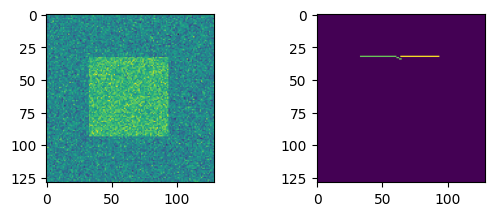

In [29]:
import cv2
import numpy as np
from threading import Lock, Thread
import math
from typing import Tuple
#from detector import Detector, MyParam  # assuming Detector class is in detector.py
import matplotlib.pyplot as plt

# Global mutex for edge map synchronization
E_mutex = Lock()

def read_image(path: str) -> np.ndarray:
    """Read image from file."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Could not open or find the image")
        exit(-1)
    return img

def show_image(image: np.ndarray):
    """Display image with OpenCV."""
    #i_big = cv2.resize(image, (0, 0), fx=scale, fy=scale)
    #win_name = f"Window {fig}"
    #cv2.namedWindow(win_name, cv2.WINDOW_AUTOSIZE)
    #cv2.imshow(win_name, i_big)
    #if wait:
    #cv2.waitKey(0)
    plt.imshow(image)
    plt.show()

def my_wrapper(I: np.ndarray, E: np.ndarray, prm: MyParam, ry: slice, rx: slice):
    """Wrapper function for edge detection on image segment."""
    d = Detector(I, prm)
    cur_E = d.run_im()
    
    with E_mutex:
        E[ry, rx] = np.maximum(E[ry, rx], cur_E)

def my_run_im(I: np.ndarray, E: np.ndarray, prm: MyParam):
    """Run edge detection on entire image."""
    if not prm.slidingWindow:
        # Process entire image at once
        E = np.zeros(I.shape, dtype=np.float64)
        my_wrapper(I, E, prm, slice(None), slice(None))
    else:
        # Process image in sliding windows
        prm.parallel = True
        prm.printToScreen = False
        
        # Calculate window size
        s = min(I.shape[1], I.shape[0])
        j = math.log2(s)
        j = math.floor(j) - 1 if j == math.floor(j) else math.floor(j)
        s = int(pow(2, j)) + 1
        s = min(s, int(prm.slidingWindow))
        
        E = np.zeros(I.shape, dtype=np.float64)
        ds = (s - 1) // 2
        
        start_time = cv2.getTickCount()
        
        total_iterations = ((I.shape[1] // ds + 1) * (I.shape[0] // ds + 1))
        print(f"{total_iterations} ITERATIONS")
        print(f"{s} BLOCK")
        
        threads = []
        parallel = False
        iter_count = 0
        
        for x in range(0, I.shape[1], ds):
            for y in range(0, I.shape[0], ds):
                # Calculate window ranges
                x_end = min(x + s, I.shape[1])
                y_end = min(y + s, I.shape[0])
                if x + s >= I.shape[1]:
                    rx = slice(I.shape[1] - s, I.shape[1])
                else:
                    rx = slice(x, x + s)
                if y + s >= I.shape[0]:
                    ry = slice(I.shape[0] - s, I.shape[0])
                else:
                    ry = slice(y, y + s)
                
                iter_count += 1
                print(f"ITER {iter_count}")
                
                cur_I = I[ry, rx]
                
                if parallel:
                    thread = Thread(target=my_wrapper, 
                                  args=(cur_I, E, prm, ry, rx))
                    threads.append(thread)
                    thread.start()
                else:
                    my_wrapper(cur_I, E, prm, ry, rx)
        
        if parallel:
            for thread in threads:
                thread.join()
        
        end_time = cv2.getTickCount()
        processing_time = (end_time - start_time) / cv2.getTickFrequency()
        print(f"Processing time: {processing_time:.2f} seconds")
    
    # Normalize edge map
    E -= E.min()
    max_val = E.max()
    if max_val > 0:
        E = E / max_val
    else:
        print("Warning: Edge map is all zeros; skipping normalization.")
    return E

def main():
    # Noisy Image Demo
    print("Noisy Image Demo:")
    I = read_image("Sqr.png")
    I = np.float64(I) / 255.0
    plt.subplot(2,2,1)
    plt.imshow(I)
    prm = MyParam()
    prm.slidingWindow = False
    prm.noisyImage = True
    prm.parallel = False # Do not change
    prm.splitPoints = 0
    prm._deubg = False
    
    E = np.zeros_like(I)
    E = my_run_im(I, E, prm)
    print(E)
    #E = 1 - E
    plt.subplot(2,2,2)
    plt.imshow(E)
    plt.show()
    return
    # Real Image Demo
    print("Real Image Demo:")
    I = read_image("2.png")
    I = np.float64(I) / 255.0
    plt.subplot(2,2,3)
    plt.imshow(I);
    prm.slidingWindow = 129
    prm.noisyImage = False
    prm.parallel = False
    prm.splitPoints = 0
    
    E = np.zeros_like(I)
    E = my_run_im(I, E, prm)
    E = 1 - E
    plt.subplot(2,2,4)
    plt.imshow(E)
    
    print("Finished")

if __name__ == "__main__":
    main()